In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_parquet('dados_clones.parquet')

In [ ]:
df.head(5)

,p2o_master_id,Massa(em kilos),General Jedi encarregado,Estatura(cm),Distância Ombro a ombro,Tamanho do crânio,Tamanho dos pés,Tempo de existência(em meses),Status
0,10578986,83.13,Yoda,180.25,Tipo 4,Tipo 1,Tipo 5,0.0,Defeituoso
1,10976676,83.08,Yoda,180.39,Tipo 3,Tipo 2,Tipo 5,0.0,Defeituoso
2,10588329,83.12,Shaak Ti,180.26,Tipo 4,Tipo 5,Tipo 5,0.0,Defeituoso
3,10254411,83.38,Shaak Ti,180.35,Tipo 2,Tipo 2,Tipo 5,0.0,Defeituoso
4,10634458,83.15,Shaak Ti,180.31,Tipo 3,Tipo 2,Tipo 2,0.0,Defeituoso


In [ ]:
df.columns = df.columns.str.strip() #Limpando nome das colunas

In [ ]:
df.shape #Vendo número de linhas e colunas do df

(1048719, 9)

In [ ]:
df[df['Status'] == "Defeituoso"].shape

(110526, 9)


#Análise bivariada

In [26]:
df[df['Status'] == "Defeituoso"].groupby("General Jedi encarregado").size()

,0
General Jedi encarregado,
Shaak Ti,55299
Yoda,55227


Percebemos que somente dois generais tem soldados defeituosos. A primeira instância, poderiamos simplesmente falar que o problema está nos generais, mas precisamos entender outras variáveis que possam impactar nesses números, variáveis as quais podem não ser dependentes dos generais mas sim dos soldados que estão em seu exército.

Até agora, nossa **conclusão final** é de que os generais Yoda e Shaak não são tão bons como os outros.

**Tomada de decisão**:
1. Reciclar treinamento com as tropas
2. Trocar os generais

In [28]:
from sklearn import tree
tree1 = tree.DecisionTreeClassifier(random_state=42)

In [77]:
X = df.drop(['Status', 'General Jedi encarregado',"Distância Ombro a ombro","Tamanho do crânio",'Tamanho dos pés',"Tempo de existência(em meses)","p2o_master_id"], axis=1) #Focando
#análise e classificação somente em atributos físicos dos clones
y = df.Status

In [65]:
X

,Massa(em kilos),Estatura(cm)
0,83.13,180.25
1,83.08,180.39
2,83.12,180.26
3,83.38,180.35
4,83.15,180.31
...,...,...
1048714,84.14,181.03
1048715,83.10,180.62
1048716,83.63,180.54
1048717,83.02,180.06


In [66]:
y

,Status
0,Defeituoso
1,Defeituoso
2,Defeituoso
3,Defeituoso
4,Defeituoso
...,...
1048714,Apto
1048715,Apto
1048716,Apto
1048717,Apto


In [67]:
features = X.columns

In [68]:
tree1.fit(X,y)

DecisionTreeClassifier(random_state=42)

[Text(0.6666666666666666, 0.9, 'Massa(em kilos) <= 83.405\ngini = 0.189\nsamples = 1048719\nvalue = [938193, 110526]\nclass = Apto'),
 Text(0.5, 0.7, 'Estatura(cm) <= 180.555\ngini = 0.436\nsamples = 344571\nvalue = [234045, 110526]\nclass = Apto'),
 Text(0.5833333333333333, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'Estatura(cm) <= 180.245\ngini = 0.497\nsamples = 205177\nvalue = [94651, 110526]\nclass = Defeituoso'),
 Text(0.16666666666666666, 0.3, 'gini = 0.0\nsamples = 53107\nvalue = [53107, 0]\nclass = Apto'),
 Text(0.5, 0.3, 'Estatura(cm) <= 180.545\ngini = 0.397\nsamples = 152070\nvalue = [41544, 110526]\nclass = Defeituoso'),
 Text(0.3333333333333333, 0.1, '\n  (...)  \n'),
 Text(0.6666666666666666, 0.1, '\n  (...)  \n'),
 Text(0.6666666666666666, 0.5, 'gini = 0.0\nsamples = 139394\nvalue = [139394, 0]\nclass = Apto'),
 Text(0.8333333333333334, 0.7, 'gini = 0.0\nsamples = 704148\nvalue = [704148, 0]\nclass = Apto'),
 Text(0.75, 0.8, '  False')]

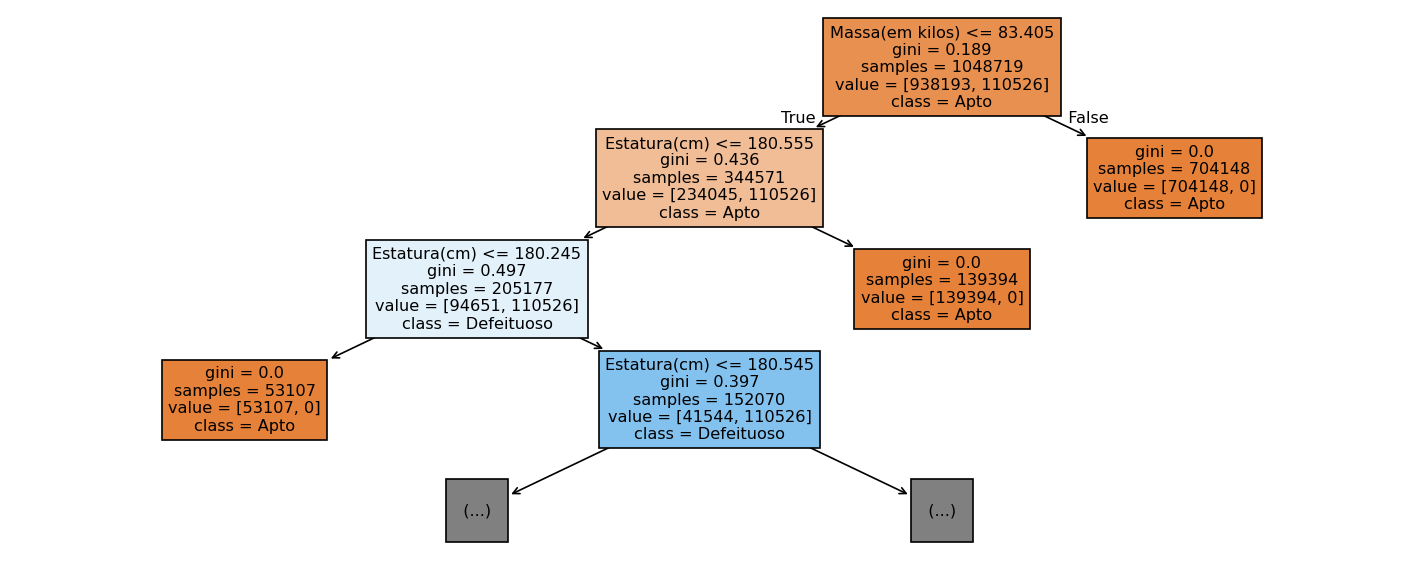

In [76]:
plt.figure(figsize=(15,6), dpi=(120))
tree.plot_tree(tree1, feature_names=features, class_names=tree1.classes_, filled=True, max_depth=3) #Max_depth = quantidade máxima de nós no plot

Essa árvore de decisão com só 3 nós, conseguiu separar 95% dos clones aptos (896.649), com base em atributos físicos. Um único nó (Pesa mais que 83.405), conseguiu separar 75% dos clones aptos (704.148). Logo depois, o segundo nó (Tem estatura maior que 180.555) conseguiu separar mais 15% dos clones aptos (139.394). Após o segundo nó, já temos **mais** clones defeituosos do que aptos. Por fim o terceiro nó (Estatura maior que 180.245), conseguiu separar mais 5% dos aptos (53.107).

Com isso, percebemos que os clones defeituosos tem menos de 83.405 e tem entre 180.245 e 180.555 de estatura. Consequentemente, podemos afirmar que os generais Yoda e Shaak tem muitos clones nessa faixa em seu exército, resultando em um número de defeituosos fora do padrão.

A **Conclusão final** agora é: Um lote de clones apresenta defeito na fabricação, defeitos referentes a massa e estatura.

**Tomada de decisão**:
1. Evitar compra de clones dentro das faixas indicadas.
2. Distribuir os clones defeituosos entree os outros generais, caso seja necessário.

In [78]:
df.groupby('Status')[features].mean() #Diferença a olho nu entre os aptos e defeituosos é quase imperceptível.

,Massa(em kilos),Estatura(cm)
Status,,
Apto,83.765887,180.605545
Defeituoso,83.200134,180.400186


#**Essa análise demonstra como a Árvore de Decisão não precisa necessariamente atuar como uma preditora de dados, mas também como uma descritora que ajuda na tomada de decisão**.